In [12]:
import google.generativeai as genai

genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

print("מודלים זמינים:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

מודלים זמינים:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-pre

<div dir=RTL>
<a href="https://colab.research.google.com/github/office268/ipynb/blob/main/langgraph_tavily_gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# סוכן AI עם LangGraph + Tavily + Gemini

סוכן פשוט שמחפש מידע באינטרנט באמצעות Tavily ועונה בעזרת מודל Gemini של Google.

In [13]:
!pip install -q langgraph langchain-google-genai langchain-community tavily-python

In [14]:
import os

try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
except Exception:
    os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"
    os.environ["TAVILY_API_KEY"] = "YOUR_TAVILY_API_KEY"

# בדיקה נוספת למפתחות API
if os.environ.get("GOOGLE_API_KEY") == "YOUR_GOOGLE_API_KEY":
    print("אזהרה: GOOGLE_API_KEY לא הוגדר כראוי. אנא הגדר אותו בסודות של Colab.")
elif os.environ.get("GOOGLE_API_KEY"): # Check if it's not empty/None
    print("GOOGLE_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).")

if os.environ.get("TAVILY_API_KEY") == "YOUR_TAVILY_API_KEY":
    print("אזהרה: TAVILY_API_KEY לא הוגדר כראוי. אנא הגדר אותו בסודות של Colab.")
elif os.environ.get("TAVILY_API_KEY"): # Check if it's not empty/None
    print("TAVILY_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).")

GOOGLE_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).
TAVILY_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).


In [15]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults

# כלי חיפוש
tools = [TavilySearchResults(max_results=3)]

# מודל Gemini עם גישה לכלי החיפוש
model = ChatGoogleGenerativeAI(
    model="gemini-pro-latest",
    google_api_key=os.environ["GOOGLE_API_KEY"]
).bind_tools(tools)

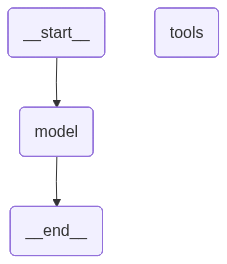

In [16]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

# צומת המודל
def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

# בדיקה: האם המודל ביקש להפעיל כלי?
def should_continue(state: MessagesState):
    return "tools" if state["messages"][-1].tool_calls else END

# בניית הגרף
graph = StateGraph(MessagesState)
graph.add_node("model", call_model)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "model")
graph.add_conditional_edges("model", should_continue)
graph.add_edge("tools", "model")

agent = graph.compile()

# הצגת הגרף
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print("START → model → tools → model → ... → END")

In [17]:
from langchain_core.messages import HumanMessage

# שאל את הסוכן שאלה
question = "מה החדשות הכי מעניינות בתחום ה-AI היום?"

result = agent.invoke({"messages": [HumanMessage(content=question)]})

# הדפסת התשובה הסופית
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'הנה כמה מהחדשות וההתפתחויות הבולטות והמעניינות ביותר בתחום הבינה המלאכותית (AI) כיום:\n\n1. **OpenAI משיקה את GPT-5.5**:\nחברת OpenAI שחררה את המודל החדש GPT-5.5. המהלך מסמן קפיצת מדרגה נוספת ומוגדר בתעשייה כצעד שמקרב את החברה לפיתוח "אפליקציית-על" (Super App) מבוססת AI, שתרכז מגוון רחב של שירותים, סוכנים ויכולות תחת קורת גג אחת.\n\n2. **גוגל מתכננת השקעת ענק של 40 מיליארד דולר ב-Anthropic**:\nמרוץ החימוש סביב כוח המחשוב (Compute) עולה שלב. גוגל מגבירה את התמיכה ב-Anthropic (המפתחת של מודלי Claude) עם תוכנית להשקעה חסרת תקדים של 40 מיליארד דולר. זהו צעד אסטרטגי משמעותי במאבק של גוגל מול השותפות של מיקרוסופט ו-OpenAI.\n\n3. **Anthropic מקימה זירת מסחר ל"סוכני AI"**:\nמעבר למודלי שפה, המיקוד כיום עובר ל-AI Agents (סוכנים אוטונומיים). Anthropic יצרה סביבת ניסוי (Marketplace) חדשנית שבה סוכני בינה מלאכותית יכולים לתקשר, לנהל משא ומתן ולבצע מסחר זה מול זה (Agent-on-agent commerce) ללא התערבות אדם.\n\n4. **רכישות חדשות בתעשייה**:\nחברת הבינה המלאכותית Sierra (שהוקמ

In [ ]:
# הדפסת התשובה הסופית
print(result["messages"][-1].content)